# Student Attendance & Performance Prediction

In this project we are using ML to predict whether a student is at risk of failing or not, based on their attendance and grades.
We also predict their final grade (G3) using regression.

Dataset: UCI Student Performance (Mathematics) - 395 students, 33 features

In [1]:
# importing all the libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

## Loading the dataset

In [2]:
df = pd.read_csv('student-mat.csv', sep=';')
print('Shape:', df.shape)
df.head()

Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [4]:
# checking for missing values
print('Missing values:', df.isnull().sum().sum())
df.describe()

Missing values: 0


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


## Feature Engineering

Creating attendance percentage from absences column

In [5]:
# converting absences to attendance percentage
# each absence = 2% reduction
df['Attendance'] = 100 - (df['absences'] * 2)
df['Attendance'] = df['Attendance'].clip(lower=0)

df[['absences', 'Attendance']].describe()

,absences,Attendance
count,395.000000,395.000000
mean,5.708861,88.759494
std,8.003096,14.758646
min,0.000000,0.000000
25%,0.000000,84.000000
50%,4.000000,92.000000
75%,8.000000,100.000000
max,75.000000,100.000000


## EDA (Exploratory Data Analysis)

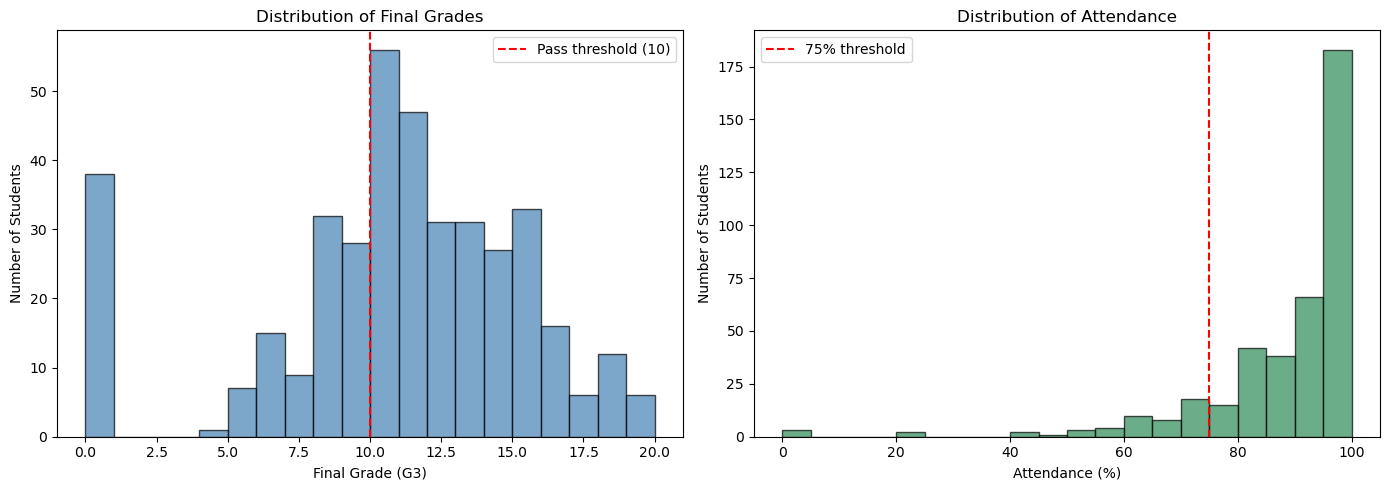

Passed: 265
Failed: 130


In [6]:
# distribution of final grades
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['G3'], bins=20, edgecolor='black', color='steelblue', alpha=0.7)
axes[0].axvline(x=10, color='red', linestyle='--', label='Pass threshold (10)')
axes[0].set_xlabel('Final Grade (G3)')
axes[0].set_ylabel('Number of Students')
axes[0].set_title('Distribution of Final Grades')
axes[0].legend()

axes[1].hist(df['Attendance'], bins=20, edgecolor='black', color='seagreen', alpha=0.7)
axes[1].axvline(x=75, color='red', linestyle='--', label='75% threshold')
axes[1].set_xlabel('Attendance (%)')
axes[1].set_ylabel('Number of Students')
axes[1].set_title('Distribution of Attendance')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Passed:', (df['G3'] >= 10).sum())
print('Failed:', (df['G3'] < 10).sum())

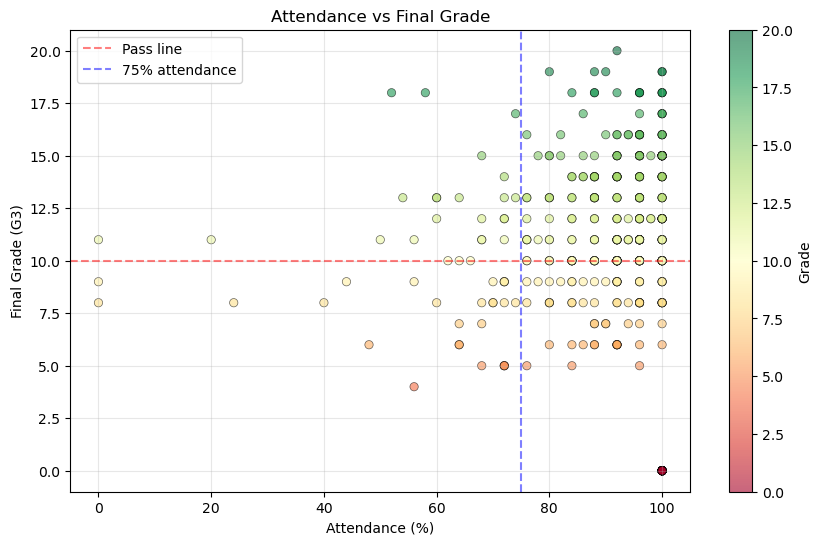

In [7]:
# scatter plot - attendance vs final grade
plt.figure(figsize=(10, 6))
plt.scatter(df['Attendance'], df['G3'], c=df['G3'], cmap='RdYlGn', alpha=0.6, edgecolors='black', linewidth=0.5)
plt.colorbar(label='Grade')
plt.xlabel('Attendance (%)')
plt.ylabel('Final Grade (G3)')
plt.title('Attendance vs Final Grade')
plt.axhline(y=10, color='red', linestyle='--', alpha=0.5, label='Pass line')
plt.axvline(x=75, color='blue', linestyle='--', alpha=0.5, label='75% attendance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

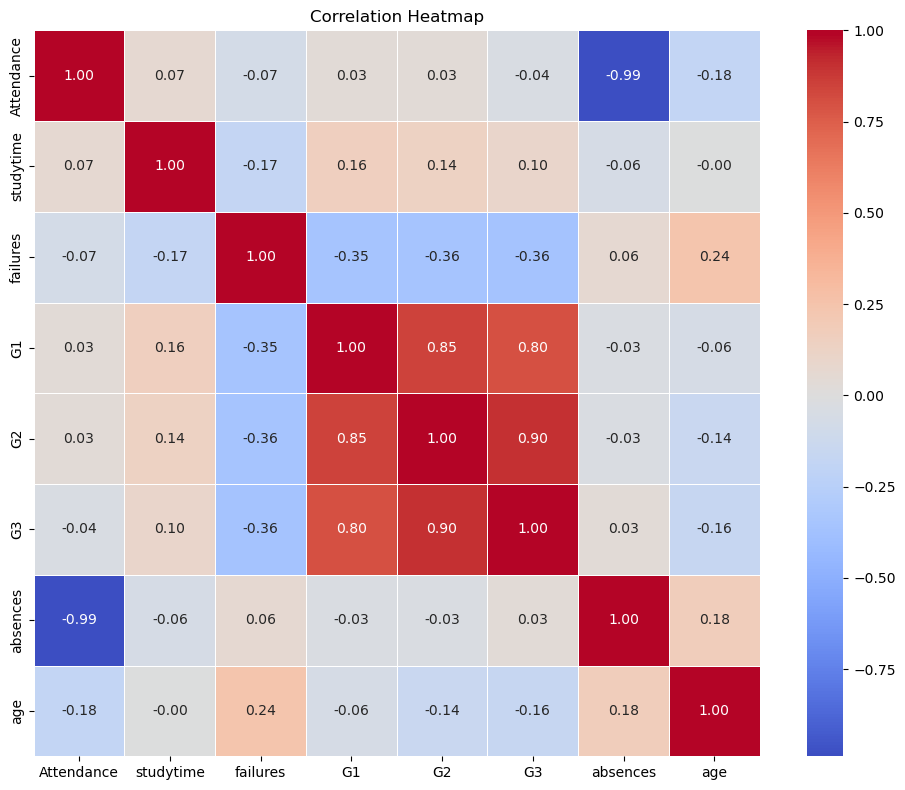

In [8]:
# correlation heatmap
plt.figure(figsize=(10, 8))
cols = ['Attendance', 'studytime', 'failures', 'G1', 'G2', 'G3', 'absences', 'age']
corr = df[cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

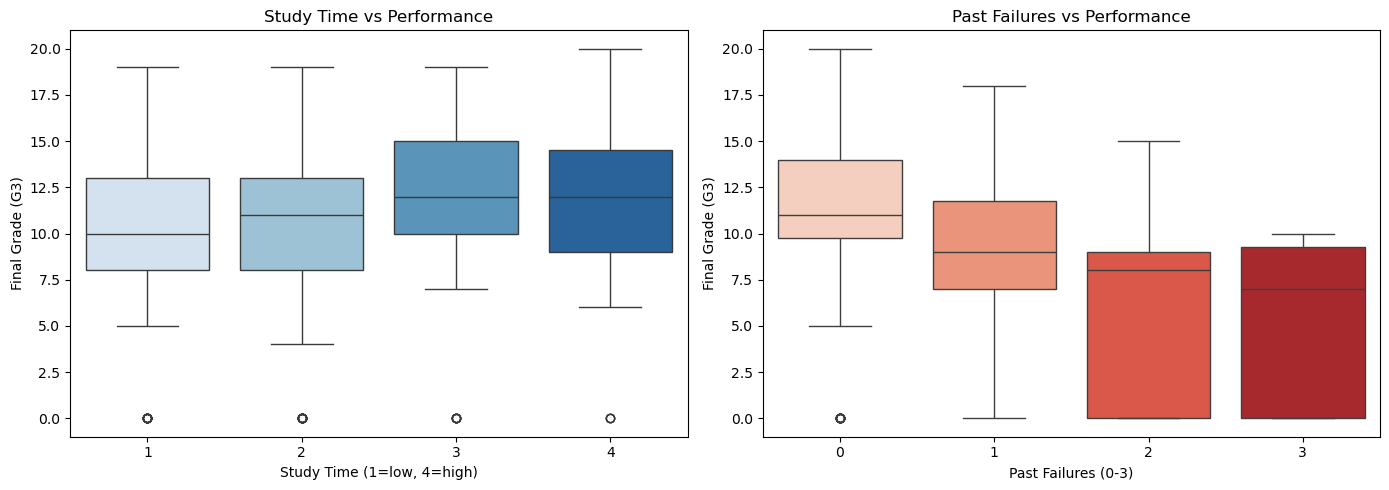

In [9]:
# studytime and failures vs grades
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x=df['studytime'], y=df['G3'], ax=axes[0], palette='Blues')
axes[0].set_xlabel('Study Time (1=low, 4=high)')
axes[0].set_ylabel('Final Grade (G3)')
axes[0].set_title('Study Time vs Performance')

sns.boxplot(x=df['failures'], y=df['G3'], ax=axes[1], palette='Reds')
axes[1].set_xlabel('Past Failures (0-3)')
axes[1].set_ylabel('Final Grade (G3)')
axes[1].set_title('Past Failures vs Performance')

plt.tight_layout()
plt.show()

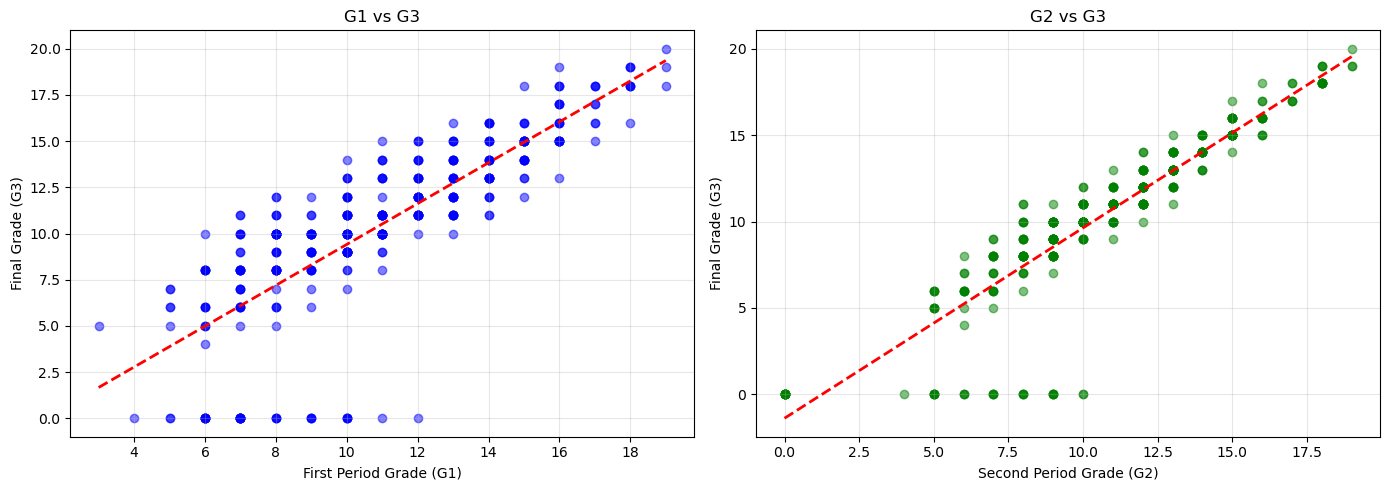

G1-G3 correlation: 0.8015
G2-G3 correlation: 0.9049


In [10]:
# how G1 and G2 relate to final grade G3
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['G1'], df['G3'], alpha=0.5, color='blue')
z1 = np.polyfit(df['G1'], df['G3'], 1)
p1 = np.poly1d(z1)
axes[0].plot(sorted(df['G1']), p1(sorted(df['G1'])), 'r--', linewidth=2)
axes[0].set_xlabel('First Period Grade (G1)')
axes[0].set_ylabel('Final Grade (G3)')
axes[0].set_title('G1 vs G3')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(df['G2'], df['G3'], alpha=0.5, color='green')
z2 = np.polyfit(df['G2'], df['G3'], 1)
p2 = np.poly1d(z2)
axes[1].plot(sorted(df['G2']), p2(sorted(df['G2'])), 'r--', linewidth=2)
axes[1].set_xlabel('Second Period Grade (G2)')
axes[1].set_ylabel('Final Grade (G3)')
axes[1].set_title('G2 vs G3')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('G1-G3 correlation:', round(df['G1'].corr(df['G3']), 4))
print('G2-G3 correlation:', round(df['G2'].corr(df['G3']), 4))

## Creating target variable

Student is At Risk if attendance < 75% or grade < 10

Target variable distribution:
At_Risk
0    240
1    155
Name: count, dtype: int64

Safe: 240
At Risk: 155


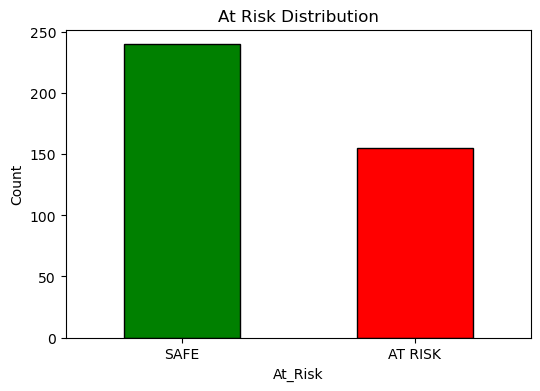

In [11]:
required_percentage = 75

df['At_Risk'] = ((df['Attendance'] < required_percentage) | (df['G3'] < 10)).astype(int)

print('Target variable distribution:')
print(df['At_Risk'].value_counts())
print()
print('Safe:', (df['At_Risk'] == 0).sum())
print('At Risk:', (df['At_Risk'] == 1).sum())

# bar plot
plt.figure(figsize=(6, 4))
df['At_Risk'].value_counts().plot(kind='bar', color=['green', 'red'], edgecolor='black')
plt.xticks([0, 1], ['SAFE', 'AT RISK'], rotation=0)
plt.ylabel('Count')
plt.title('At Risk Distribution')
plt.show()

## Preparing data for training

In [12]:
features = ['Attendance', 'studytime', 'failures', 'G1', 'G2']

X = df[features]
y = df['At_Risk']   # for classification
g3 = df['G3']       # for regression

print('Features:', features)
print('X shape:', X.shape)

Features: ['Attendance', 'studytime', 'failures', 'G1', 'G2']
X shape: (395, 5)


In [13]:
# 80-20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training:', X_train.shape[0])
print('Testing:', X_test.shape[0])

Training: 316
Testing: 79


In [14]:
# scaling features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression (Classification)

Predicting whether student is at risk or safe

In [15]:
clf_lr = LogisticRegression(random_state=42, max_iter=1000)
clf_lr.fit(X_train_scaled, y_train)

y_pred_lr = clf_lr.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)
print('Logistic Regression Accuracy:', round(acc_lr * 100, 2), '%')

Logistic Regression Accuracy: 87.34 %


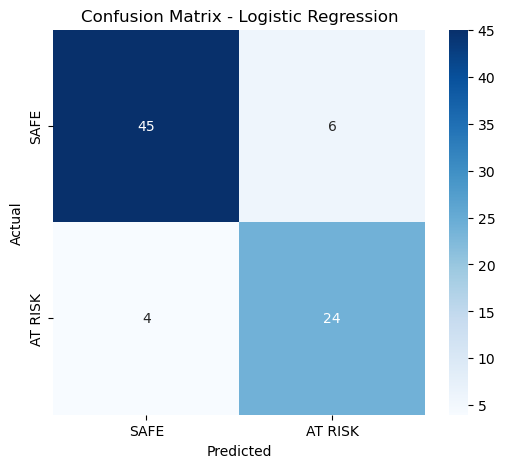

In [16]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['SAFE', 'AT RISK'], yticklabels=['SAFE', 'AT RISK'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [17]:
# classification report
print(classification_report(y_test, y_pred_lr, target_names=['SAFE', 'AT RISK']))

              precision    recall  f1-score   support

        SAFE       0.92      0.88      0.90        51
     AT RISK       0.80      0.86      0.83        28

    accuracy                           0.87        79
   macro avg       0.86      0.87      0.86        79
weighted avg       0.88      0.87      0.87        79



## Linear Regression (Grade Prediction)

Predicting final grade G3 (0-20)

In [18]:
reg_model = LinearRegression()
reg_model.fit(X_train_scaled, g3.loc[y_train.index])

g3_test = g3.loc[y_test.index]
g3_pred = reg_model.predict(X_test_scaled)

r2 = r2_score(g3_test, g3_pred)
mae = mean_absolute_error(g3_test, g3_pred)
rmse = np.sqrt(mean_squared_error(g3_test, g3_pred))

print('R2 Score:', round(r2, 4))
print('MAE:', round(mae, 4))
print('RMSE:', round(rmse, 4))

R2 Score: 0.7816
MAE: 1.3497
RMSE: 2.1164


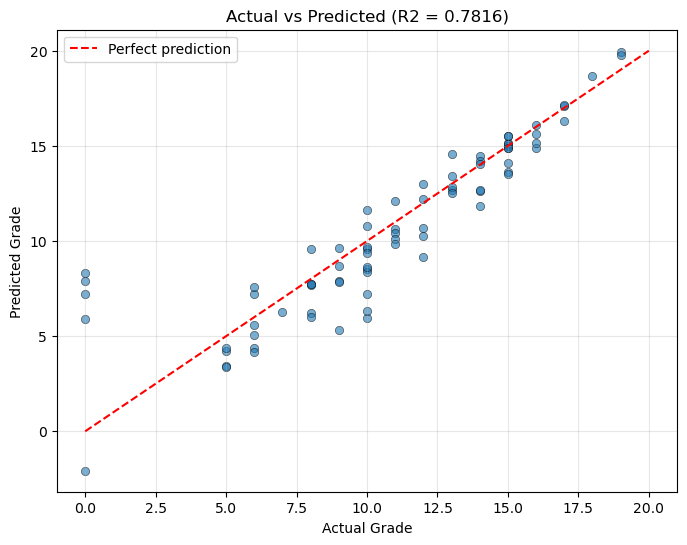

In [19]:
# actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(g3_test, g3_pred, alpha=0.6, edgecolors='black', linewidth=0.5)
plt.plot([0, 20], [0, 20], 'r--', label='Perfect prediction')
plt.xlabel('Actual Grade')
plt.ylabel('Predicted Grade')
plt.title('Actual vs Predicted (R2 = ' + str(round(r2, 4)) + ')')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Model Comparison

Comparing logistic regression with random forest and SVM

In [20]:
# random forest
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
clf_rf.fit(X_train_scaled, y_train)
y_pred_rf = clf_rf.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, y_pred_rf)

# SVM
clf_svm = SVC(kernel='rbf', random_state=42)
clf_svm.fit(X_train_scaled, y_train)
y_pred_svm = clf_svm.predict(X_test_scaled)
acc_svm = accuracy_score(y_test, y_pred_svm)

print('Logistic Regression:', round(acc_lr*100, 2), '%')
print('Random Forest:', round(acc_rf*100, 2), '%')
print('SVM:', round(acc_svm*100, 2), '%')

Logistic Regression: 87.34 %
Random Forest: 92.41 %
SVM: 92.41 %


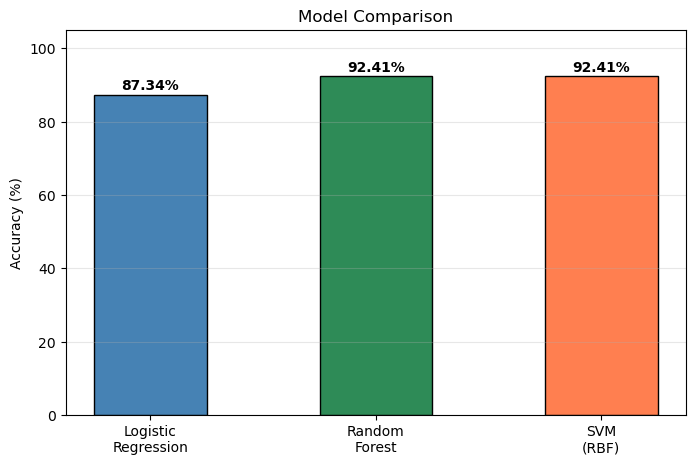

In [21]:
# bar chart
models = ['Logistic\nRegression', 'Random\nForest', 'SVM\n(RBF)']
accuracies = [acc_lr*100, acc_rf*100, acc_svm*100]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['steelblue', 'seagreen', 'coral'], edgecolor='black', width=0.5)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             str(round(acc, 2)) + '%', ha='center', va='bottom', fontweight='bold')

plt.ylabel('Accuracy (%)')
plt.title('Model Comparison')
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [22]:
# classification reports for other models
print('Random Forest:')
print(classification_report(y_test, y_pred_rf, target_names=['SAFE', 'AT RISK']))

print('\nSVM:')
print(classification_report(y_test, y_pred_svm, target_names=['SAFE', 'AT RISK']))

Random Forest:
              precision    recall  f1-score   support

        SAFE       0.96      0.92      0.94        51
     AT RISK       0.87      0.93      0.90        28

    accuracy                           0.92        79
   macro avg       0.91      0.93      0.92        79
weighted avg       0.93      0.92      0.92        79


SVM:
              precision    recall  f1-score   support

        SAFE       0.94      0.94      0.94        51
     AT RISK       0.89      0.89      0.89        28

    accuracy                           0.92        79
   macro avg       0.92      0.92      0.92        79
weighted avg       0.92      0.92      0.92        79



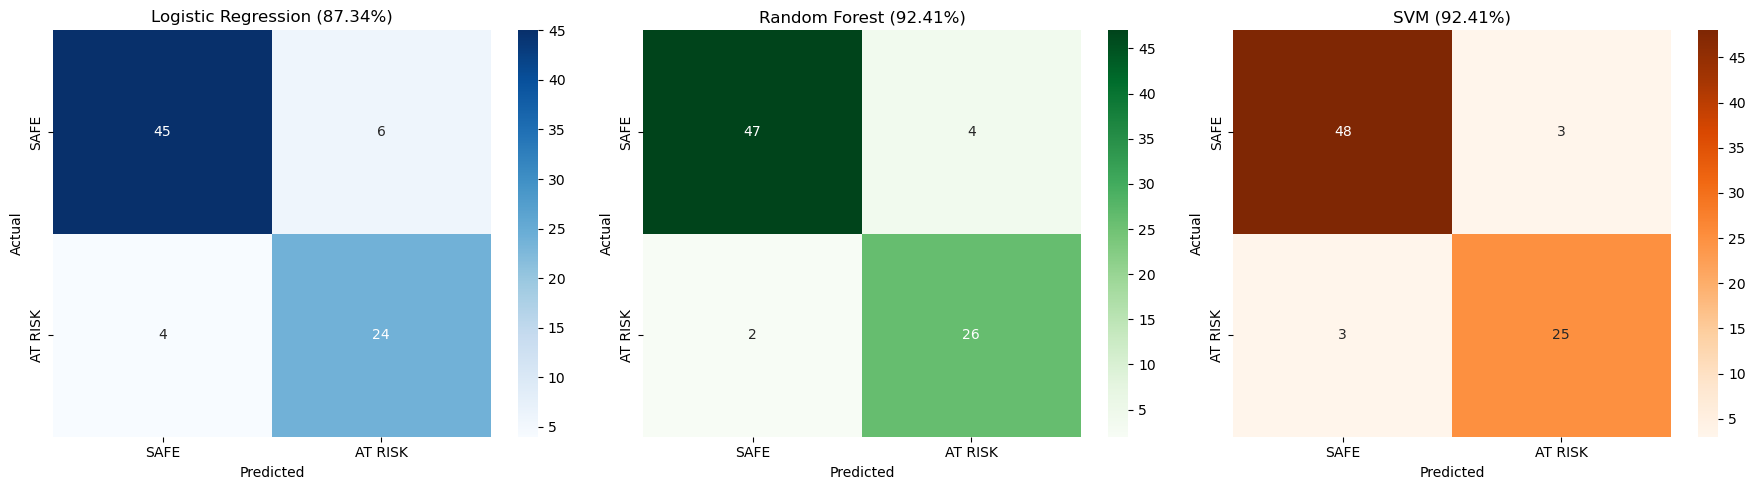

In [23]:
# confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, pred, name, cmap in zip(axes,
    [y_pred_lr, y_pred_rf, y_pred_svm],
    ['Logistic Regression', 'Random Forest', 'SVM'],
    ['Blues', 'Greens', 'Oranges']):
    
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['SAFE', 'AT RISK'], yticklabels=['SAFE', 'AT RISK'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    acc = accuracy_score(y_test, pred)
    ax.set_title(name + ' (' + str(round(acc*100, 2)) + '%)')

plt.tight_layout()
plt.show()

## Testing with a sample student

In [24]:
# sample student: attendance=80%, studytime=2, failures=1, G1=10, G2=12
sample = pd.DataFrame([[80, 2, 1, 10, 12]], columns=features)
sample_scaled = scaler.transform(sample)

print('Logistic Regression:', 'AT RISK' if clf_lr.predict(sample_scaled)[0] == 1 else 'SAFE')
print('Random Forest:', 'AT RISK' if clf_rf.predict(sample_scaled)[0] == 1 else 'SAFE')
print('SVM:', 'AT RISK' if clf_svm.predict(sample_scaled)[0] == 1 else 'SAFE')
print()
print('Predicted Grade:', round(reg_model.predict(sample_scaled)[0], 2), '/ 20')

Logistic Regression: SAFE
Random Forest: SAFE
SVM: SAFE

Predicted Grade: 11.41 / 20


## Conclusion

- G2 has the strongest correlation with G3 (final grade)
- Past failures negatively affect performance
- Random Forest and SVM gave better accuracy than Logistic Regression
- But Logistic Regression is simpler and still gives good results (87%)
- The model can be used to identify at-risk students early